In [26]:
import pandas as pd
import numpy as np


In [27]:

df_density_pvap = pd.read_csv(r"U:\\Github\\BayesianThompsonSamplingOptimization\\COSMOtherm\\outputfiles\\PVAP_antoine_density_ingested.csv")
df_density_pvap.columns
# Index(['file_name', 'compound_name', 'A', 'B', 'C', 'Ae', 'Be', 'Ce', 'De',
#        'Ee', 'Fe', 'Ge', 'Density', 'Volume', 'T_boil'],
#       dtype='object')
df_density_pvap.rename(columns={
    'compound_name': 'COSMO_name',
}, inplace=True)
df_density_pvap

,file_name,COSMO_name,A,B,C,Ae,Be,Ce,De,Ee,Fe,Ge,Density,Volume,T_boil
0,"PVAP_((1,1-dimethylethoxy)methyl)oxirane.tab","((1,1-dimethylethoxy)methyl)oxirane",14.886922,4309.862179,-48.986889,70.561179,-9715.127817,0.0,0.0,-7.509910,213660.000000,-2.0,0.936082,0.230939,468.700085
1,PVAP_((1-methylethyl)thio)benzene.tab,((1-methylethyl)thio)benzene,15.375815,4914.968851,-45.113846,80.858740,-11344.927396,0.0,0.0,-8.823097,303790.000000,-2.0,0.994358,0.254265,502.002249
2,"PVAP_(+)-(1'r,2's,4's)-(e)-beta-santalol.tab","(+)-(1'r,2's,4's)-(e)-beta-santalol",15.360536,5456.554793,-88.762868,50.383497,-7096.525182,0.0,0.0,-4.977771,-796940.000000,-2.0,0.940354,0.389112,596.717769
3,"PVAP_(+)-(1'r,2's,4's)-beta-santalol.tab","(+)-(1'r,2's,4's)-beta-santalol",15.409626,5468.361742,-88.646701,50.575031,-7124.905542,0.0,0.0,-4.996609,-795340.000000,-2.0,0.933421,0.392002,595.385043
4,"PVAP_(+)-(1'r,3's,6's)-3'-methyl-norlimbanol.tab","(+)-(1'r,3's,6's)-3'-methyl-norlimbanol",15.933207,5812.319409,-81.935554,56.565167,-8346.586967,0.0,0.0,-5.682195,-637950.000000,-2.0,0.869114,0.459361,595.623940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11897,PVAP_[chloro(difluoro)methyl]formate.tab,[chloro(difluoro)methyl]formate,13.671998,2314.283642,-61.564961,48.370731,-5584.598516,0.0,0.0,-4.694335,88602.032917,-2.0,1.463160,0.148080,317.183399
11898,"PVAP_[cis-4-[(1r)-2,2,3-trimethylcyclopent-3-e...","[cis-4-[(1r)-2,2,3-trimethylcyclopent-3-en-1-y...",15.288501,5614.327350,-90.520929,48.471028,-6886.489129,0.0,0.0,-4.757200,-895360.000000,-2.0,0.942885,0.391617,616.691431
11899,"PVAP_[cis-4-[(1s)-2,2,3-trimethylcyclopent-3-e...","[cis-4-[(1s)-2,2,3-trimethylcyclopent-3-en-1-y...",15.284744,5621.165808,-90.255691,48.300656,-6892.103657,0.0,0.0,-4.732484,-891210.000000,-2.0,0.943848,0.391218,617.252613
11900,PVAP_[dichloro(fluoro)methoxy]ethane.tab,[dichloro(fluoro)methoxy]ethane,14.364345,3238.145051,-48.687955,62.318789,-7927.315469,0.0,0.0,-6.464208,220920.000000,-2.0,1.276044,0.191263,380.941311


In [28]:

cosmo_index = pd.read_csv(r"U:\Github\BayesianThompsonSamplingOptimization\cosmobase_info_final.csv")
liqex_data = pd.read_csv(r"U:\Github\BayesianThompsonSamplingOptimization\COSMOtherm\outputfiles\Screening\LIQEX_all.csv")

cosmo_index["COSMO_name"]
cosmo_index["SMILES"]

# merge SMILES  data onto liqex_data via COSMO_name
liqex_data = liqex_data.merge(cosmo_index[["COSMO_name", "SMILES"]], on="COSMO_name", how="left")

# merge Density and T_boil data onto liqex_data via COSMO_name
liqex_data = liqex_data.merge(df_density_pvap[["COSMO_name", "Density", "T_boil"]], on="COSMO_name", how="left")

# U:\Github\BayesianThompsonSamplingOptimization\Datafiles\solvents.csv


#del Unnamed: 0
liqex_data.drop(columns=["Unnamed: 0"], inplace=True)


# liqex_data.set_index("COSMO_name", inplace=True)
liqex_data.columns
# Index(['carrier_phase_1_N', 'carrier_phase_1_W', 'carrier_phase_1_x',
#        'carrier_phase_2_N', 'carrier_phase_2_W', 'carrier_phase_2_x',
#        'carrier_Kx(1,2)', 'solute_phase_1_N', 'solute_phase_1_W',
#        'solute_phase_1_x', 'solute_phase_2_N', 'solute_phase_2_W',
#        'solute_phase_2_x', 'solute_Kx(1,2)', 'solvent_phase_1_N',
#        'solvent_phase_1_W', 'solvent_phase_1_x', 'solvent_phase_2_N',
#        'solvent_phase_2_W', 'solvent_phase_2_x', 'solvent_Kx(1,2)',
#        'file_name', 'SMILES'],
#       dtype='object')

#Tboil smaller than 110 C
# liqex_data = liqex_data[liqex_data["T_boil"] < 110 + 273.15]  # Convert to Kelvin



# liqex_data["Selectivity"] = liqex_data["solute_Kx(1,2)"] / (liqex_data["carrier_Kx(1,2)"] * liqex_data["solvent_Kx(1,2)"])
# liqex_data["Selectivity"].sort_values(ascending=False)[:50]

def reassign_phase(row):
    if row["solvent_phase_1_W"] > row["solvent_phase_2_W"]:
        phase = 0
    else:
        phase = 1
    return phase

def flip_data_in_df(row, phase):
    if phase:
        row["carrier_phase_1_N"], row["carrier_phase_2_N"] = row["carrier_phase_2_N"], row["carrier_phase_1_N"]
        row["carrier_phase_1_W"], row["carrier_phase_2_W"] = row["carrier_phase_2_W"], row["carrier_phase_1_W"]
        row["carrier_phase_1_x"], row["carrier_phase_2_x"] = row["carrier_phase_2_x"], row["carrier_phase_1_x"]
        row["solute_phase_1_N"], row["solute_phase_2_N"] = row["solute_phase_2_N"], row["solute_phase_1_N"]
        row["solute_phase_1_W"], row["solute_phase_2_W"] = row["solute_phase_2_W"], row["solute_phase_1_W"]
        row["solute_phase_1_x"], row["solute_phase_2_x"] = row["solute_phase_2_x"], row["solute_phase_1_x"]
        row["solvent_phase_1_N"], row["solvent_phase_2_N"] = row["solvent_phase_2_N"], row["solvent_phase_1_N"]
        row["solvent_phase_1_W"], row["solvent_phase_2_W"] = row["solvent_phase_2_W"], row["solvent_phase_1_W"]
        row["solvent_phase_1_x"], row["solvent_phase_2_x"] = row["solvent_phase_2_x"], row["solvent_phase_1_x"]
    return row

#same as above but one df level for efficiency


liqex_data["Phase"] = liqex_data.apply(reassign_phase, axis=1)
liqex_data = liqex_data.apply(lambda row: flip_data_in_df(row, row["Phase"]), axis=1)
liqex_data["Phase"].value_counts()

Phase
1    4570
0     307
Name: count, dtype: int64

In [29]:

experimental_solvents = pd.read_csv(r"U:\Github\BayesianThompsonSamplingOptimization\Datafiles\solvents.csv")


In [30]:

x = "solute_phase_1_W"
y = "solute_phase_1_x"
z = "carrier_phase_1_W"

from paretoset import paretoset
mask = paretoset(liqex_data[[x, z]], sense=["max", "min"], use_numba=False)

liqex_data["Pareto"] = mask

array([[<Axes: title={'center': 'Selectivity'}>]], dtype=object)

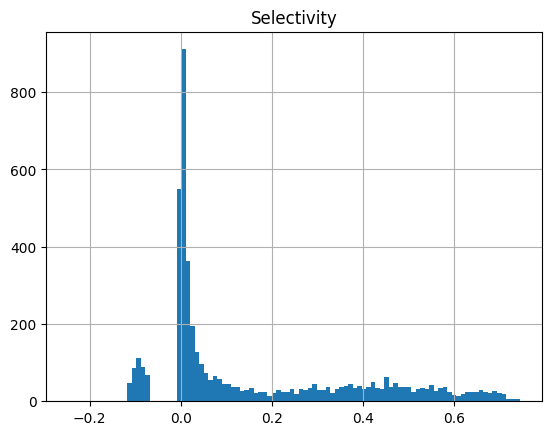

In [31]:


#Calculate selectivity
liqex_data["Selectivity"] = liqex_data["solute_Kx(1,2)"] / (liqex_data["carrier_Kx(1,2)"] + 1)

#scale all Kx(1,2) values to be between 0 and 1
for col in liqex_data.filter(regex=r"_W$|_Kx(1,2)$").columns:
    liqex_data[f"{col}_norm"] = (liqex_data[col] - liqex_data[col].min()) / (liqex_data[col].max() - liqex_data[col].min())
# liqex_data["Selectivity"] = liqex_data["solute_Kx(1,2)"] + (liqex_data["solvent_Kx(1,2)"] - liqex_data["carrier_Kx(1,2)"])

#chebysheff performance metric
def chebysheff_performance(row):
    return np.log(2+np.min([
        row["solute_phase_1_W_norm"],
        1-row["carrier_phase_1_W_norm"]
    ]))

# liqex_data["Selectivity"] = liqex_data.apply(chebysheff_performance, axis=1)

liqex_data["Selectivity"] = liqex_data["solute_phase_1_W_norm"] - (liqex_data["carrier_phase_1_W_norm"])

# liqex_data.to_csv(r"U:\Github\BayesianThompsonSamplingOptimization\Datafiles\LIQEX_COSMObase.csv", index=False)

exp_liqex_data = liqex_data[liqex_data["COSMO_name"].isin(experimental_solvents["COSMO_name"])]
liqex_data.hist(column="Selectivity", bins=100)

array([[<Axes: title={'center': 'solute_phase_1_W'}>]], dtype=object)

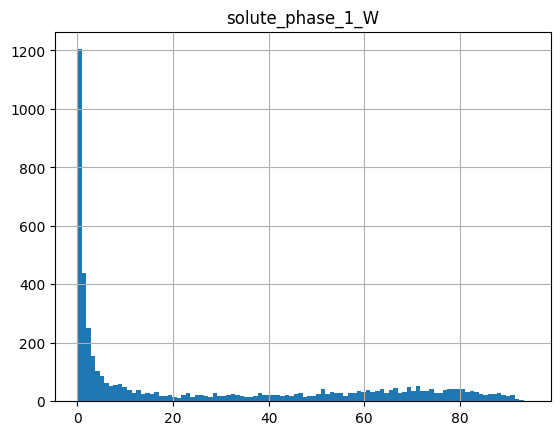

In [32]:
liqex_data.hist(column="solute_phase_1_W", bins=100)

In [33]:

# Get the top 50 by selectivity
top50 = liqex_data.nlargest(50, "Selectivity")["Selectivity"]
top50_df = liqex_data.loc[top50.index]
# top50_df = liqex_data[liqex_data["Pareto"]] 

#columns containing _W AND _Kx(1,2) AND selectivity, also render nicely
# top50_df.filter(regex=r"_W$|_x$|_Kx\(1,2\)$|Selectivity|COSMO_name").head(50).round(2).style.background_gradient(
#     cmap="viridis"
# )
top50_df.filter(regex=r"_W|_Kx|Selectivity|COSMO_name|Density|T_boil|Phase").head(50).round(2).style.background_gradient(
    cmap="viridis"
)

,carrier_phase_1_W,carrier_phase_2_W,"carrier_Kx(1,2)",solute_phase_1_W,solute_phase_2_W,"solute_Kx(1,2)",solvent_phase_1_W,solvent_phase_2_W,"solvent_Kx(1,2)",COSMO_name,Density,T_boil,Phase,Selectivity,carrier_phase_1_W_norm,carrier_phase_2_W_norm,solute_phase_1_W_norm,solute_phase_2_W_norm,solvent_phase_1_W_norm,solvent_phase_2_W_norm
1699,107.400000,809.740000,2.170000,83.470000,16.530000,0.060000,788.420000,0.310000,0.000000,1-octanamine,0.790000,446.110000,1,0.740000,0.140000,0.860000,0.880000,0.120000,0.150000,0.000000
2812,117.760000,799.380000,2.060000,84.470000,15.530000,0.060000,794.180000,0.790000,0.000000,3-(trimethylsilyl)-1-propanamine,0.790000,396.100000,1,0.740000,0.150000,0.850000,0.900000,0.100000,0.150000,0.000000
1695,86.130000,831.020000,2.330000,80.500000,19.500000,0.060000,793.720000,0.110000,0.000000,1-nonanamine,0.790000,467.460000,1,0.740000,0.110000,0.890000,0.850000,0.150000,0.150000,0.000000
1609,132.470000,784.680000,2.040000,86.080000,13.920000,0.060000,780.970000,0.830000,0.000000,1-heptanamine,0.780000,422.800000,1,0.740000,0.170000,0.830000,0.910000,0.090000,0.150000,0.000000
1300,120.010000,797.140000,2.030000,84.220000,15.780000,0.060000,785.920000,1.180000,0.000000,1-(trimethylsilyl)-2-propanamine,0.790000,387.170000,1,0.740000,0.160000,0.840000,0.890000,0.110000,0.150000,0.000000
2446,118.930000,798.220000,2.150000,83.790000,16.210000,0.060000,772.520000,0.830000,0.000000,2-heptanamine,0.770000,418.220000,1,0.730000,0.160000,0.840000,0.890000,0.110000,0.150000,0.000000
2667,115.100000,802.050000,2.070000,83.260000,16.740000,0.060000,782.800000,1.220000,0.000000,2-trimethylsilylpropan-1-amine,0.780000,380.920000,1,0.730000,0.150000,0.850000,0.880000,0.120000,0.150000,0.000000
2194,97.780000,819.370000,2.260000,80.920000,19.080000,0.060000,775.600000,0.380000,0.000000,2-amino-6-methylheptane,0.780000,439.090000,1,0.730000,0.130000,0.870000,0.860000,0.140000,0.150000,0.000000
3240,120.640000,796.500000,2.120000,83.440000,16.560000,0.060000,767.270000,1.300000,0.000000,4-methyl-2-hexanamine,0.770000,410.910000,1,0.730000,0.160000,0.840000,0.880000,0.120000,0.140000,0.000000
2388,93.550000,823.600000,2.330000,80.060000,19.940000,0.070000,782.030000,0.430000,0.000000,2-ethylhexylamine,0.780000,436.050000,1,0.730000,0.120000,0.880000,0.850000,0.150000,0.150000,0.000000


In [37]:
import plotly.express as px
import plotly.graph_objects as go
print(liqex_data)

#basic amine filter
amine_list = ["amin", "amid", "ine"]
liqex_data = liqex_data[~liqex_data["COSMO_name"].str.contains('|'.join(amine_list), case=False, na=False)]
print(liqex_data)

print(exp_liqex_data)

x = "solute_phase_1_W"
y = "solute_phase_1_x"
z = "Selectivity"


fig = px.scatter(
    liqex_data,
    x=x,
    y=y,
    color=z,
    title="Selectivity vs Solute Phase 1 W and X", 
    hover_data=["COSMO_name", "solute_phase_1_W", "solute_phase_1_x", "carrier_phase_1_W"],
)


fig.add_trace(
    go.Scatter(
        x=exp_liqex_data[x],
        y=exp_liqex_data[y],
        mode="markers",
        marker=dict(
            symbol="square",
            size=10,
            color=exp_liqex_data[z],  # fill colour
            line=dict(color="black", width=1.5),   # black outline
        ),
        text=exp_liqex_data["COSMO_name"],
        hovertemplate=(
            "COSMO_name: %{text}<br>" +
            f"{x}: %{{x}}<br>" +
            f"{y}: %{{y}}<br>" +
            "Selectivity: %{marker.color}<extra></extra>"
        ),
        name="Experimental"
    )
)


fig.update_layout(
    coloraxis_colorbar=dict(title="Selectivity"),
    width=800,
    height=600,
    template="plotly_white",
)
fig.show()


      carrier_phase_1_N  carrier_phase_1_W  carrier_phase_1_x  \
0              8.535150         153.763486           0.521310   
1              8.535150         153.763486           0.521310   
2              8.197710         147.684406           0.467985   
3              8.197710         147.684406           0.467985   
4              0.883127          15.909820           0.120417   
...                 ...                ...                ...   
4872           2.369418          42.685838           0.175069   
4873           0.091961           1.656705           0.009757   
4874           0.989766          17.830960           0.080734   
4875           0.082921           1.493845           0.009460   
4876           0.022520           0.405696           0.006737   

      carrier_phase_2_N  carrier_phase_2_W  carrier_phase_2_x  \
0             42.374155         763.384138           0.989188   
1             42.374155         763.384138           0.989188   
2             42.711595 

In [35]:
top50_df.head(1)
# 	carrier_phase_1_N	carrier_phase_1_W	carrier_phase_1_x	carrier_phase_2_N	carrier_phase_2_W	carrier_phase_2_x	carrier_Kx(1,2)	solute_phase_1_N	solute_phase_1_W	solute_phase_1_x	...	solvent_phase_1_N	solvent_phase_1_W	solvent_phase_1_x	solvent_phase_2_N	solvent_phase_2_W	solvent_phase_2_x	solvent_Kx(1,2)	file_name	SMILES	Selectivity
# COSMO_name																					
# diethylaminopropylamine	10.81698	194.871406	0.598671	40.092325	722.276217	0.996737	0.600631	0.996851	89.794647	0.055171	...	6.254497	814.535283	0.346158	0.017946	2.337117	0.000446	775.875966	LIQEX_diethylaminopropylamine_tc40.0_W1100.0.tab	N(CCCN)(CC)CC	32.61202

# # # Map roles
# role_map = ['carrier', 'solute', 'solvent'] 

# # solvent_name = filepath regex
# filename = os.path.basename(filepath)
# match = re.search(r'LIQEX_(.*?)_tc', filename)
# if match:
#     solvent_name = match.group(1)
# else:
#     solvent_name = df["Nr Compound"].to_list()[-1]

# df["Nr Compound"] = role_map

# df.set_index('Nr Compound', inplace=True)

# # Flatten the DataFrame
# flattened = df.stack()
# flattened.index = [f"{idx}_{col}" for idx, col in flattened.index]
# flattened_df = pd.DataFrame([flattened])
# flattened_df["COSMO_name"] = [solvent_name]

# return flattened_df

# unflatten the top candidate again

def unflatten_df_row(row, rename_columns=False):
    """
    Takes a single DataFrame row (e.g., top50_df.iloc[0]) and returns a DataFrame
    with three rows: one each for carrier, solute, and solvent, with their properties.
    """
    # Convert to dict for easier handling
    row_dict = row.to_dict()
    roles = ['carrier', 'solute', 'solvent']
    # Find all property suffixes (e.g., phase_1_N, phase_1_W, Kx(1,2), etc.)
    prop_suffixes = set()
    for col in row.index:
        for role in roles:
            if col.startswith(role + '_'):
                prop_suffixes.add(col[len(role)+1:])
    prop_suffixes = sorted(prop_suffixes)
    
    # Build the output rows
    output = []
    for role in roles:
        role_data = {'Role': role}
        for suffix in prop_suffixes:
            colname = f"{role}_{suffix}"
            if colname in row_dict:
                role_data[suffix] = row_dict[colname]
        # Add common info
        role_data['COSMO_name'] = row_dict.get('COSMO_name', None)
        role_data['Selectivity'] = row_dict.get('Selectivity', None)
        role_data['SMILES'] = row_dict.get('SMILES', None)
        output.append(role_data)

    uf_df = pd.DataFrame(output)
    # reverse all column names at underscores phase_1_N --> N_1_phase with double for loop
    if rename_columns:
        rename_dict = { col: '_'.join(reversed(col.split('_'))) if '_' in col else col for col in uf_df.columns }
        print(rename_dict)
        uf_df.rename(columns=rename_dict, inplace=True)
        #sort columns alphabetically
        uf_df = uf_df.reindex(sorted(uf_df.columns), axis=1)
        
    return uf_df

# Example usage:
# for 
unflattened = unflatten_df_row(top50_df.iloc[0])

unflattened = unflattened.round(2)  # Round to 2 decimal places
unflattened.style.background_gradient(cmap="viridis").format(precision=2)
display(unflattened)
# Role	Kx(1,2)	phase_1_N	phase_1_W	phase_1_x	phase_2_N	phase_2_W	phase_2_x	COSMO_name	Selectivity	SMILES
# 0	carrier	0.00	28.86	519.87	0.77	22.05	397.28	0.77	1,1,2-trifluoroethanol	0.69	C(C(O)(F)F)F
# 1	solute	0.00	0.63	56.68	0.02	0.48	43.32	0.02	1,1,2-trifluoroethanol	0.69	C(C(O)(F)F)F
# 2	solvent	0.01	8.06	806.01	0.21	6.16	615.95	0.21	1,1,2-trifluoroethanol	0.69	C(C(O)(F)F)F

import plotly.express as px

from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from io import BytesIO
from PIL import Image
import os

def comp_bar_plot(unflattened, property="x", path=None):
    """
    Creates a stacked bar plot with an inset image of the molecule for the given unflattened DataFrame.
    """
    # Check if png exists
    # plt.savefig(f"{path}/PhaseCompPlot_{property}_{unflattened['COSMO_name'].values[0]}.png", bbox_inches='tight', dpi=300)
    if os.path.exists(f"{path}/PhaseCompPlot_{property}_{unflattened['COSMO_name'].values[0]}.png"):
        print(f"Plot already exists for {unflattened['COSMO_name'].values[0]}, skipping.")
        return

    # Melt the DataFrame
    bar_df = unflattened.melt(id_vars=["Role", "COSMO_name", "Selectivity", "SMILES"],
                              value_vars=["phase_1_N", "phase_1_W", "phase_1_x",
                                          "phase_2_N", "phase_2_W", "phase_2_x"],   
                              var_name="Property", value_name="Value")
    bar_df["Phase"] = bar_df["Property"].apply(lambda x: x.split('_')[1])
    bar_df["Property"] = bar_df["Property"].apply(lambda x: x.split('_')[-1])

    sub_x_bar_df = bar_df[bar_df["Property"] == property]

    pivot_df = sub_x_bar_df.pivot(index='Phase', columns='Role', values='Value').fillna(0)

    # --- Begin plotting ---
    fig, ax = plt.subplots(figsize=(4, 4))


    pivot_df.plot(kind='bar', stacked=True, colormap='viridis', edgecolor='black', linewidth=1.5, ax=ax)

    ax.set_ylabel(f"{property.upper()} Value")
    ax.set_title(f'Solvent: {unflattened["COSMO_name"].values[0]}, Score: {unflattened["Selectivity"].values[0]:.2f}')
    ax.set_xticks(range(len(pivot_df.index)))
    ax.set_xticklabels(pivot_df.index, rotation=0)
    # below x axis legend one line
    ax.legend(title='Role', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.tight_layout()

    # Draw molecule and insert as image
    smiles = unflattened["SMILES"].values[0]
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        # Create PIL image from RDKit Mol
        img = Draw.MolToImage(mol, size=(200, 200))
        buf = BytesIO()
        img.save(buf, format='PNG')
        buf.seek(0)
        pil_img = Image.open(buf)

        # Add inset axes next to the main plot
        inset_ax = inset_axes(ax, width="25%", height="25%", loc='upper right', borderpad=1)

        inset_ax.imshow(pil_img)
        inset_ax.axis('off')

    # plt.show()
    plt.savefig(f"{path}/PhaseCompPlot_{property}_{unflattened['COSMO_name'].values[0]}.png", bbox_inches='tight', dpi=300)

from pathlib import Path

path = Path("./output_images/")
path.mkdir(parents=True, exist_ok=True)

for idx, row in top50_df.iterrows():
    unflattened = unflatten_df_row(row)
    print(f"Plotting for {unflattened['COSMO_name'].values[0]}, SMILES: {unflattened['SMILES'].values[0]}")

    # display(unflattened.style.background_gradient(cmap="viridis").format(precision=2))
    # Call the plotting function
    comp_bar_plot(unflattened, property="W", path=path)

,Role,"Kx(1,2)",phase_1_N,phase_1_W,phase_1_W_norm,phase_1_x,phase_2_N,phase_2_W,phase_2_W_norm,phase_2_x,COSMO_name,Selectivity,SMILES
0,carrier,2.17,5.96,107.40,0.14,0.46,44.95,809.74,0.86,1.0,1-octanamine,0.74,CCCCCCCCN
1,solute,0.06,0.93,83.47,0.88,0.07,0.18,16.53,0.12,0.0,1-octanamine,0.74,CCCCCCCCN
2,solvent,0.00,6.10,788.42,0.15,0.47,0.00,0.31,0.00,0.0,1-octanamine,0.74,CCCCCCCCN


ModuleNotFoundError: No module named 'rdkit'

In [ ]:
top50_df = liqex_data.loc[top50.index]


fig = px.scatter_ternary(
    top50_df,
    a="solute_phase_2_x",
    b="carrier_phase_2_x",
    c="solvent_phase_2_x",
    color="Selectivity",
    title="Ternary Plot of Solute, Carrier, and Solvent Phase 1 X vs Selectivity",
    hover_data=["COSMO_name", "solute_phase_1_W", "carrier_phase_1_W", "solvent_phase_1_W"],
)

#add phase 1 to ternary plot
fig.add_trace(
    px.scatter_ternary(
        top50_df,
        a="solute_phase_1_x",
        b="carrier_phase_1_x",
        c="solvent_phase_1_x",
        color="Selectivity",
        hover_data=["COSMO_name", "solute_phase_1_W", "carrier_phase_1_W", "solvent_phase_1_W"],
    ).data[0]
)

#connect pairs of points with lines from phase 1 to phase 2 based on COSMO_name

for name in top50_df["COSMO_name"].unique():
    unfl_df = top50_df[top50_df["COSMO_name"] == name].iloc[0]

    subset = pd.DataFrame({
        "solute_x": [unfl_df["solute_phase_1_x"], unfl_df["solute_phase_2_x"]],
        "carrier_x": [unfl_df["carrier_phase_1_x"], unfl_df["carrier_phase_2_x"]],
        "solvent_x": [unfl_df["solvent_phase_1_x"], unfl_df["solvent_phase_2_x"]],
        "COSMO_name": [unfl_df["COSMO_name"], unfl_df["COSMO_name"]],
        "Selectivity": [unfl_df["Selectivity"], unfl_df["Selectivity"]],
    })    
    
    # display(subset.style.background_gradient(cmap="viridis").format(precision=2))

    if len(subset) > 1:
        fig.add_trace(
            px.line_ternary(
                subset,
                a="solute_x",
                b="carrier_x",
                c="solvent_x",
                line_group="COSMO_name",
            ).data[0]
        )

fig.update_layout(
    coloraxis_colorbar=dict(title="Selectivity"),
    width=800,
    height=600,
    template="plotly_white",
    ternary=dict(
        aaxis_title="Solute",
        baxis_title="Carrier",
        caxis_title="Solvent",
    )
)

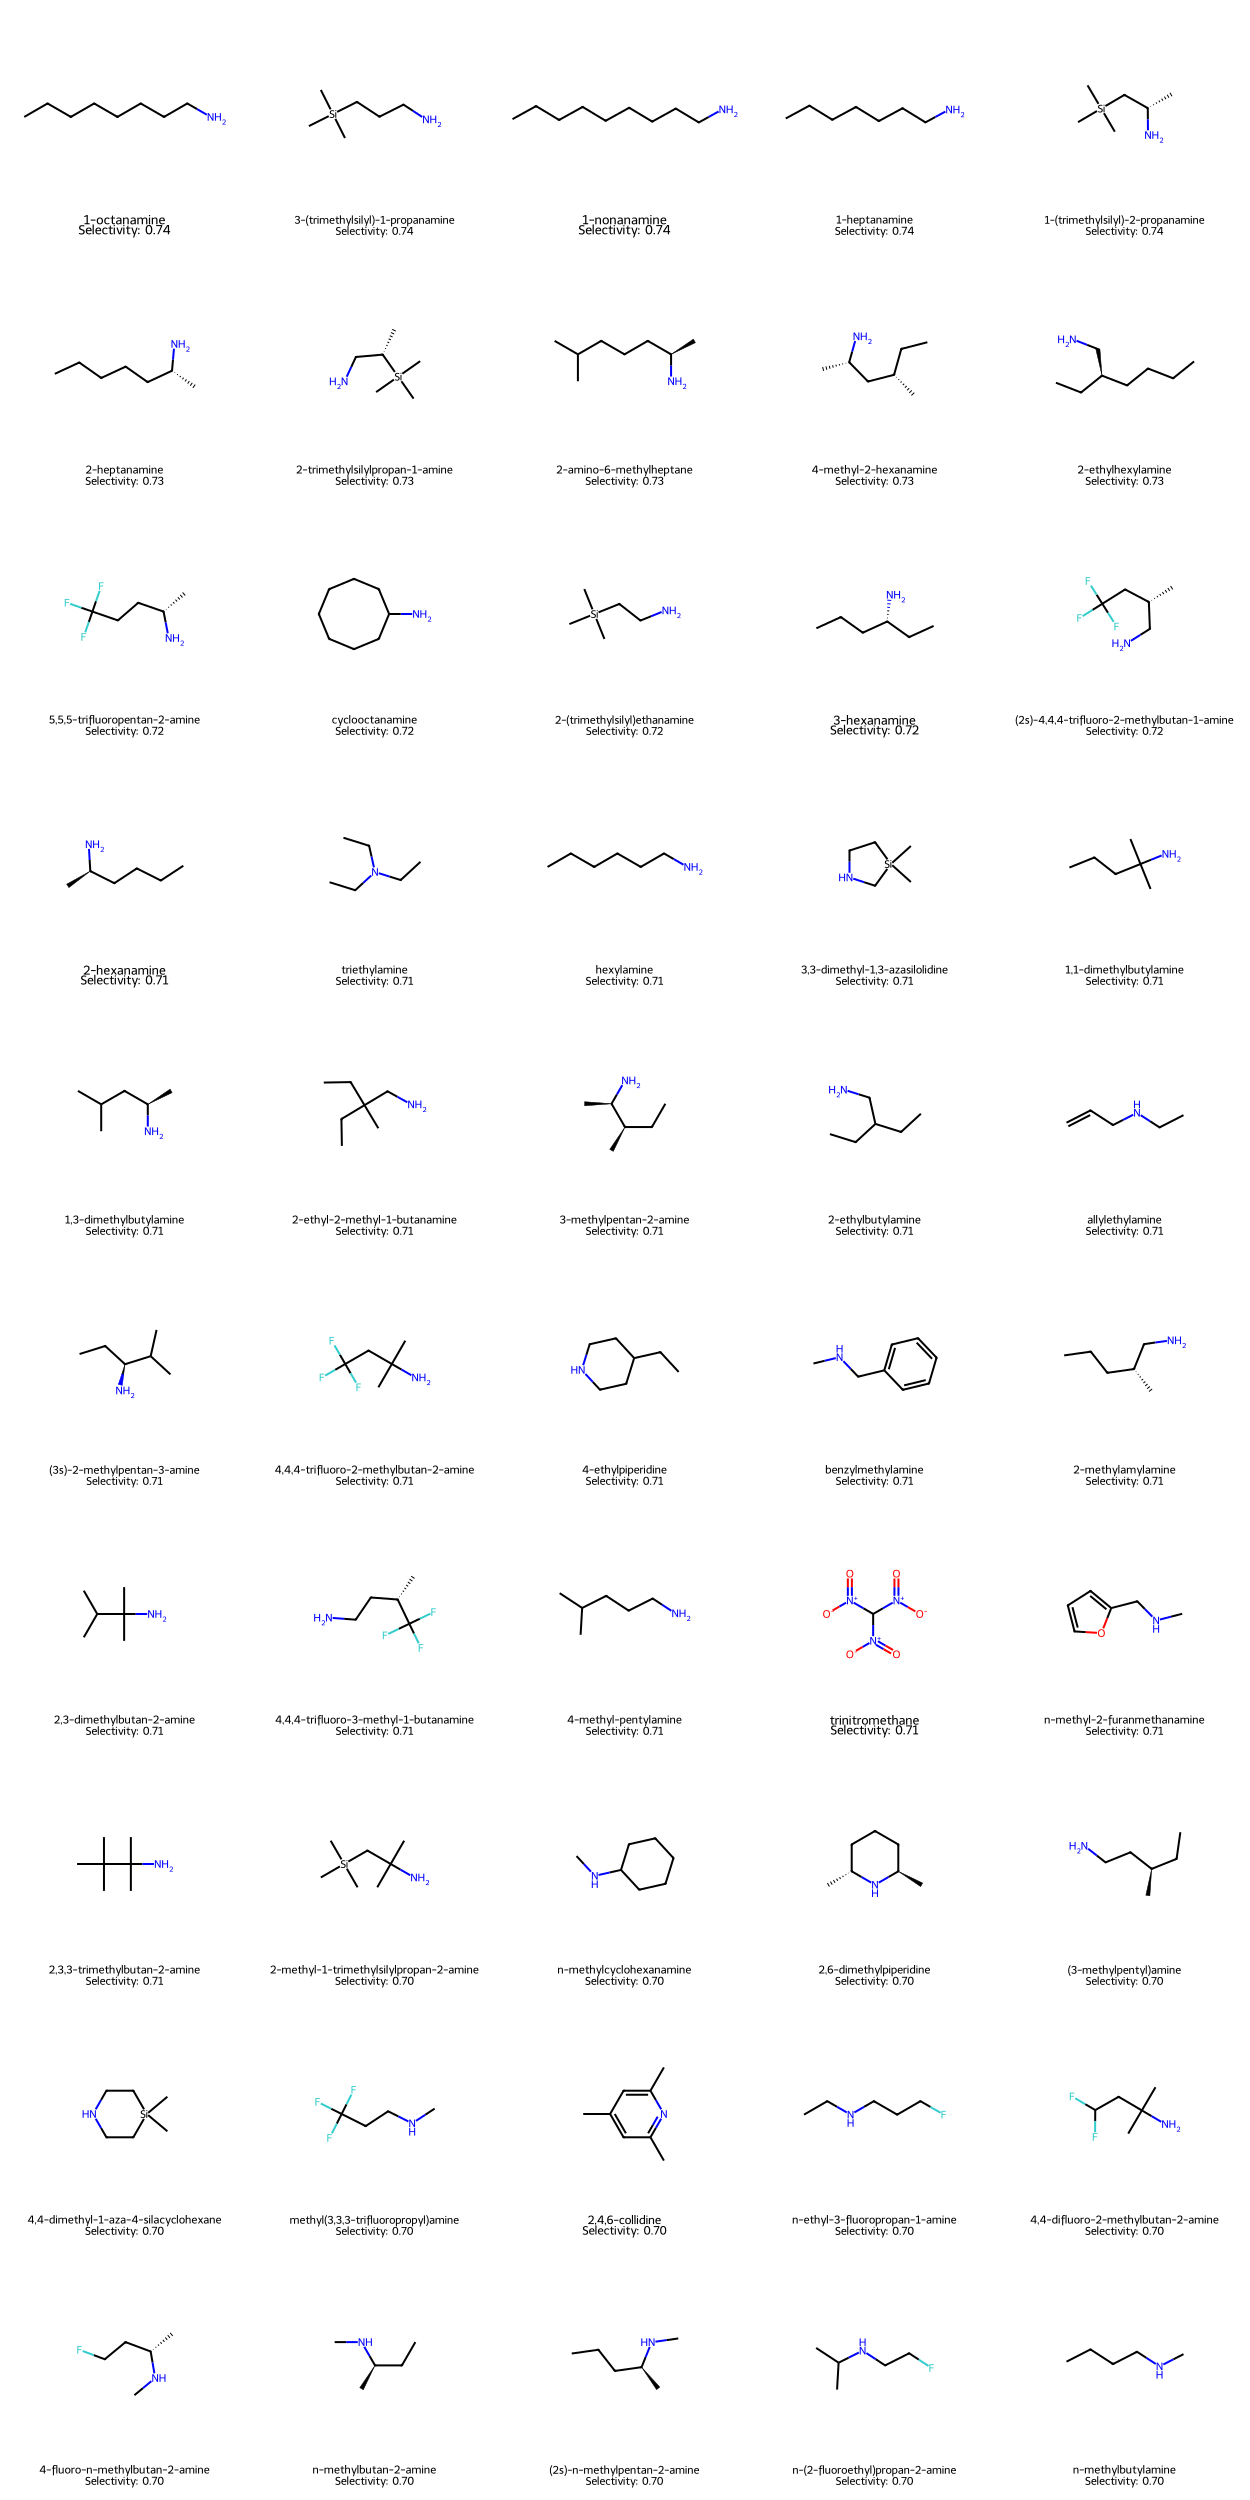

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

# Get SMILES, names, and selectivity values
smiles_list = top50_df["SMILES"].tolist()
names_list = top50_df["COSMO_name"].tolist()
selectivities = top50_df["Selectivity"].tolist()

# Convert SMILES to RDKit Mol objects (skip if SMILES is NaN or invalid)
mols = []
legends = []
for smi, name, sel in zip(smiles_list, names_list, selectivities):
    if pd.notnull(smi):
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            mols.append(mol)
            legends.append(f"{name}\nSelectivity: {sel:.2f}")

# Draw molecules in a grid with names and selectivity
img = Draw.MolsToGridImage(mols, molsPerRow=5, legends=legends, subImgSize=(250,250))
img